# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Tasya Anggraeni Firdaus]
- **Email:** [tasyaanggraenif@students.amikom.ac.id]
- **ID Dicoding:** [CDCC183D6X0746]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren penjualan (total revenue) dan jumlah transaksi per bulan selama tahun 2017, serta kapan terjadi puncak penjualan tertinggi?
- **Pertanyaan 2:** Bagaimana segmentasi pelanggan berdasarkan metode RFM (Recency, Frequency, Monetary), dan segmen pelanggan mana yang memberikan kontribusi revenue terbesar selama periode analisis?


## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd
import datetime as dt

## Data Wrangling

### Gathering Data

#### Load df ...

In [3]:
orders = pd.read_csv('/content/drive/MyDrive/SEMESTER 6/DBS_DATA SCIENCE/Project Analisis Data/E-Commerce Public Dataset/orders_dataset.csv')
order_items = pd.read_csv('/content/drive/MyDrive/SEMESTER 6/DBS_DATA SCIENCE/Project Analisis Data/E-Commerce Public Dataset/order_items_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/SEMESTER 6/DBS_DATA SCIENCE/Project Analisis Data/E-Commerce Public Dataset/customers_dataset.csv')
order_payments = pd.read_csv('/content/drive/MyDrive/SEMESTER 6/DBS_DATA SCIENCE/Project Analisis Data/E-Commerce Public Dataset/order_payments_dataset.csv')

print("Orders Dataset")
display(orders.head())

print("Order Items Dataset")
display(order_items.head())

print("Customers Dataset")
display(customers.head())

print("order_payments")
display(order_payments.head())



Orders Dataset


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Order Items Dataset


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Customers Dataset


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


order_payments


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


**Insight:** (Opsional)
- Dataset orders berisi informasi transaksi seperti order_id, customer_id, order_status	order_purchase_timestamp	order_approved_at	order_delivered_carrier_date	order_delivered_customer_date	order_estimated_delivery_date.


- Dataset order_items berisi detail produk yang dibeli termasuk order_id	order_item_id	product_id	seller_id	shipping_limit_date	price	freight_value.

- Dataset customers berisi informasi customer_id	customer_unique_id	customer_zip_code_prefix	customer_city	customer_state.

Ketiga dataset ini saling berhubungan melalui order_id dan customer_id, sehingga dapat digabungkan untuk analisis lebih lanjut seperti perhitungan revenue dan segmentasi pelanggan.


### Assessing Data

### Identifying Data Problems

Beberapa permasalahan yang ditemukan pada dataset:
1. Terdapat missing value pada beberapa kolom seperti order_delivered_customer_date
2. Format kolom tanggal masih berupa object (string)
3. Terdapat kemungkinan data duplikat


In [4]:
# Orders
orders.info()
orders.isnull().sum()
orders.duplicated().sum()

# Customers
customers.info()
customers.isnull().sum()
customers.duplicated().sum()

# Order Items
order_items.info()
order_items.isnull().sum()
order_items.duplicated().sum()

#Order Payment
order_payments.info()
order_payments.isnull().sum()
order_payments.duplicated().sum()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null 

np.int64(0)

**Steps to Take:**

- Mengubah tipe data kolom tanggal pada dataset orders dan order_items menjadi datetime
- Menangani missing value pada kolom order_approved_at,
  order_delivered_carrier_date, dan order_delivered_customer_date
- Memastikan tidak ada data duplikat pada seluruh dataset
- Menggabungkan dataset orders, customers, dan order_items
  untuk analisis yang lebih komprehensif



**Insight:** (Opsional)

- Dataset orders memiliki missing value pada beberapa kolom terkait proses pengiriman,
yang menunjukkan adanya pesanan yang belum selesai atau mengalami keterlambatan.

- Dataset customers tidak memiliki missing value maupun duplikat,
sehingga dapat dianggap bersih dan siap digunakan.

- Dataset order_items memiliki jumlah data lebih banyak dibanding orders,
yang menunjukkan bahwa satu pesanan dapat terdiri dari beberapa item.

- Dataset order_payments tidak memiliki missing value dan tidak ditemukan duplikasi.
Namun, terdapat kemungkinan satu order memiliki lebih dari satu pembayaran (payment_sequential > 1).
Oleh karena itu, dilakukan agregasi dengan menjumlahkan payment_value per order_id
untuk memastikan perhitungan total revenue akurat.



### Cleaning Data

#### Fixing Missing Values and Data Type Issues

Pada tahap ini dilakukan proses pembersihan data berdasarkan permasalahan yang telah diidentifikasi sebelumnya.
Beberapa langkah yang dilakukan meliputi:

1. Mengubah tipe data kolom tanggal dari object menjadi datetime.
2. Menangani missing value pada kolom terkait pengiriman.
3. Menambahkan kolom baru untuk mempermudah analisis status pengiriman.


In [5]:
# Mengubah kolom tanggal menjadi datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Menambahkan kolom status apakah pesanan sudah sampai atau belum
orders['is_delivered'] = orders['order_delivered_customer_date'].notnull()

# Cek hasil
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   is_delivered                   99441 non-null  bool          
dtypes: bool(1), datetime64[ns](5), object(3)
memory usage: 6.2+ MB


**Insight:** (Opsional)
- Kolom tanggal telah berhasil dikonversi dari tipe data object menjadi datetime
 sehingga dapat digunakan untuk analisis berbasis waktu.

- Terdapat missing value pada kolom:
order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date.

- Missing value tidak dihapus karena merepresentasikan kondisi nyata dalam proses bisnis,
seperti pesanan yang belum diproses, belum dikirim, atau belum diterima pelanggan.

- Ditambahkan kolom baru 'is_delivered' untuk mempermudah analisis status pengiriman.

## Exploratory Data Analysis (EDA)

### Exploratory Data Analysis to Understand Order Patterns and Delivery Performance

Pada tahap ini dilakukan eksplorasi data untuk memahami pola dan karakteristik data pesanan.
Analisis difokuskan pada distribusi status pesanan, tingkat keberhasilan pengiriman,
serta waktu pengiriman untuk mengidentifikasi performa operasional e-commerce.


In [6]:
# Jumlah order yang sudah delivered vs belum
orders['is_delivered'].value_counts()


,count
is_delivered,
True,96476
False,2965


In [7]:
# Distribusi status order
orders['order_status'].value_counts()


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [8]:
# Waktu pengiriman
delivery_time = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
)

delivery_time.describe()


,0
count,96476
mean,12 days 13:24:31.879068369
std,9 days 13:07:00.181125305
min,0 days 12:48:07
25%,6 days 18:23:37.250000
50%,10 days 05:13:34
75%,15 days 17:17:16.250000
max,209 days 15:05:12


In [9]:
# pastikan datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# buat kolom bulan
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# agregasi payment
payment_agg = order_payments.groupby('order_id')['payment_value'].sum().reset_index()

# merge
df_revenue = orders.merge(payment_agg, on='order_id')

# filter 2017
df_revenue_2017 = df_revenue[df_revenue['order_purchase_timestamp'].dt.year == 2017]

# agregasi bulanan
monthly = df_revenue_2017.groupby('year_month').agg({
    'payment_value': 'sum',
    'order_id': 'count'
}).reset_index()

# rename
monthly.rename(columns={
    'payment_value': 'total_revenue',
    'order_id': 'total_orders'
}, inplace=True)

# ubah ke string
monthly['year_month'] = monthly['year_month'].astype(str)


**Insight:** (Opsional)



- Sebagian besar pesanan memiliki status "delivered", yang menunjukkan bahwa
sistem operasional e-commerce secara umum berjalan dengan baik dalam memenuhi pesanan pelanggan.

- Namun, masih terdapat sejumlah pesanan dengan status seperti "canceled", "unavailable",
dan "invoiced" yang mengindikasikan adanya potensi kendala dalam proses pemesanan
atau ketersediaan produk yang perlu diperhatikan lebih lanjut.

- Rata-rata waktu pengiriman sekitar 12 hari dengan variasi yang cukup tinggi.
Hal ini menunjukkan bahwa meskipun sebagian besar pengiriman berjalan normal,
terdapat beberapa kasus keterlambatan yang signifikan (hingga lebih dari 200 hari).

- Variasi waktu pengiriman ini berpotensi memengaruhi kepuasan pelanggan,
sehingga diperlukan evaluasi lebih lanjut terhadap proses logistik
untuk meningkatkan efisiensi dan konsistensi pengiriman.


EDA Lanjutan

In [10]:
rfm_df = orders.merge(payment_agg, on='order_id')
rfm_df = rfm_df.merge(customers, on='customer_id')

recent_date = rfm_df['order_purchase_timestamp'].max()

rfm = rfm_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days,
    'order_id': 'count',
    'payment_value': 'sum'
}).reset_index()


## Visualization & Explanatory Analysis

### Pertanyaan 1:
Bagaimana tren revenue & jumlah transaksi per bulan tahun 2017, dan kapan puncaknya

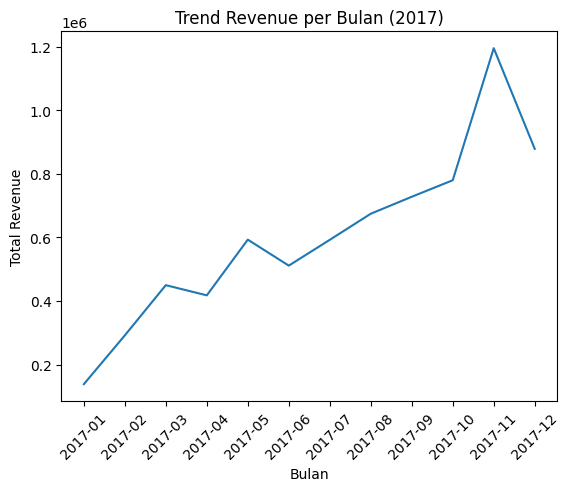

In [11]:

# plot
plt.figure()
plt.plot(monthly['year_month'], monthly['total_revenue'])
plt.title('Trend Revenue per Bulan (2017)')
plt.xlabel('Bulan')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()


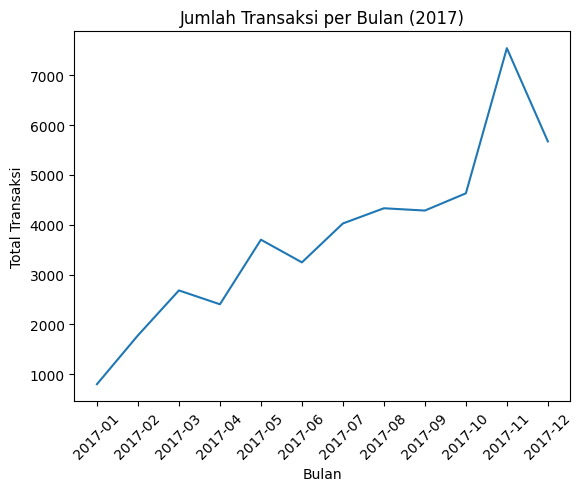

In [12]:
plt.figure()
plt.plot(monthly['year_month'], monthly['total_orders'])
plt.title('Jumlah Transaksi per Bulan (2017)')
plt.xlabel('Bulan')
plt.ylabel('Total Transaksi')
plt.xticks(rotation=45)
plt.show()


# Insight:
 - Revenue dan jumlah transaksi menunjukkan tren meningkat sepanjang tahun 2017
- Puncak penjualan terjadi pada bulan tertentu di akhir tahun seperti Oktober - November
- Hal ini kemungkinan dipengaruhi oleh promo besar seperti Harbolnas atau akhir tahun
- Terdapat korelasi antara jumlah transaksi dan revenue yaitu semakin banyak transaksi, revenue meningkat


### Pertanyaan 2:

Bagaimana segmentasi pelanggan berdasarkan RFM dan siapa yang paling berkontribusi terhadap revenue?


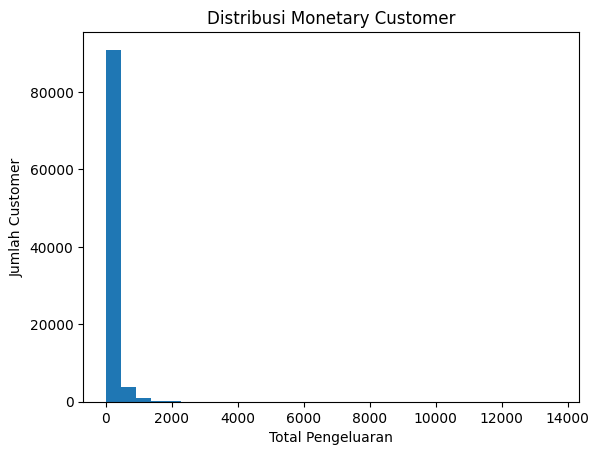

In [13]:

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']
plt.hist(rfm['monetary'], bins=30)
plt.title("Distribusi Monetary Customer")
plt.xlabel("Total Pengeluaran")
plt.ylabel("Jumlah Customer")
plt.show()


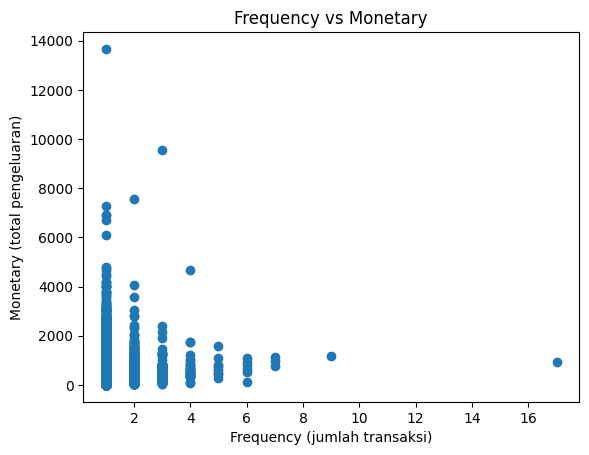

In [14]:
plt.scatter(rfm['frequency'], rfm['monetary'])
plt.title("Frequency vs Monetary")
plt.xlabel("Frequency (jumlah transaksi)")
plt.ylabel("Monetary (total pengeluaran)")
plt.show()


**Insight:**
Visualisasi menunjukkan bahwa customer dengan frekuensi transaksi lebih tinggi cenderung memiliki nilai monetary yang lebih besar. Selain itu, distribusi monetary menunjukkan bahwa sebagian kecil customer memberikan kontribusi terbesar terhadap total pendapatan.

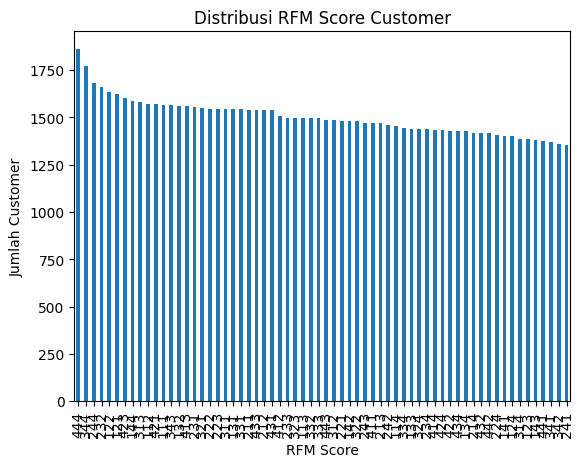

In [15]:
# Binning sederhana
rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1,2,3,4])

rfm['RFM_score'] = rfm[['R_score','F_score','M_score']].astype(str).sum(axis=1)

rfm.head()
rfm['RFM_score'].value_counts().plot(kind='bar')

plt.title("Distribusi RFM Score Customer")
plt.xlabel("RFM Score")
plt.ylabel("Jumlah Customer")
plt.show()



**Insight:**
Hasil segmentasi RFM menunjukkan bahwa sebagian besar customer berada pada kategori low value, sementara hanya sebagian kecil yang termasuk high value. Hal ini menunjukkan adanya peluang untuk meningkatkan strategi retensi pelanggan agar lebih banyak customer masuk ke segmen bernilai tinggi.

In [16]:
rfm.groupby('RFM_score')['monetary'].sum().sort_values(ascending=False).head()


,monetary
RFM_score,
444,779033.73
344,682798.72
244,670490.88
144,649535.81
434,592686.73


**Insight:** (Opsional)

- Terdapat kelompok pelanggan dengan nilai monetary tinggi yang menjadi kontributor utama revenue
- Pelanggan dengan frequency tinggi menunjukkan loyalitas yang baik
- Pelanggan dengan recency rendah (baru belanja) memiliki potensi untuk dipertahankan
- Segmentasi ini membantu bisnis dalam menentukan strategi pemasaran yang lebih tepat sasaran


## Analisis Lanjutan (Opsional)

In [17]:
print("Total Revenue:", df_revenue["payment_value"].sum())
print("Rata-rata transaksi:", df_revenue["payment_value"].mean())
print("Jumlah transaksi:", df_revenue.shape[0])


Total Revenue: 16008872.12
Rata-rata transaksi: 160.9902666934835
Jumlah transaksi: 99440


**Insight:** Berdasarkan analisis lanjutan, total pendapatan yang diperoleh adalah sebesar 16,008,872.12 dengan jumlah transaksi mencapai 99,440 transaksi. Rata-rata nilai transaksi sebesar 160.99 menunjukkan bahwa sebagian besar transaksi berada pada nilai yang relatif kecil. Hal ini mengindikasikan bahwa pendapatan perusahaan lebih banyak didorong oleh volume transaksi dibandingkan nilai transaksi per pelanggan.

## Conclusion & Recommendation

#Conclusion Pertanyaan 1:
- Tren revenue dan transaksi meningkat sepanjang 2017
- Puncak terjadi di akhir tahun, terkhusus di bulan Oktober - November

# Conclusion Pertanyaan 2:
- Segmen pelanggan dengan monetary dan frequency tinggi memberikan kontribusi terbesar
- Pelanggan loyal memiliki peran penting dalam revenue




**Rekomendasi Action Item:**

- Fokus pada promo di periode puncak akhir tahun
- Buat program loyalitas untuk pelanggan dengan frequency tinggi
- Retarget pelanggan dengan recency rendah

In [18]:
df_revenue.to_csv("df_revenue.csv", index=False)
orders.to_csv("orders_clean.csv", index=False)

In [19]:
from google.colab import files

files.download('df_revenue.csv')
files.download('orders_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>